In [ ]:
import pandas as pd
import glob
import os

path = "data/*_clean.csv" 
files = glob.glob(path)

all_dfs = []

for f in files:
    df = pd.read_csv(f)
    
    file_name = os.path.basename(f)
    country_from_file = file_name.replace('_clean.csv', '').capitalize()
    
    df['Country'] = country_from_file
    
    all_dfs.append(df)
    print(f"✅ Loaded {country_from_file} with {len(df)} rows.")

df_master = pd.concat(all_dfs, ignore_index=True)

print("\n--- Final Check ---")
print(f"Total rows in Master DF: {len(df_master)}")
print(f"Countries confirmed: {df_master['Country'].unique()}")

✅ Loaded Ethiopia with 4108 rows.
✅ Loaded Kenya with 4108 rows.
✅ Loaded Nigeria with 4108 rows.
✅ Loaded Sudan with 4108 rows.
✅ Loaded Tanzania with 4108 rows.

--- Final Check ---
Total rows in Master DF: 20540
Countries confirmed: ['Ethiopia' 'Kenya' 'Nigeria' 'Sudan' 'Tanzania']


C:\Users\Bitan\AppData\Local\Temp\ipykernel_6340\2971092252.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='T2M_MAX', data=df_master, estimator='mean', palette='rocket')


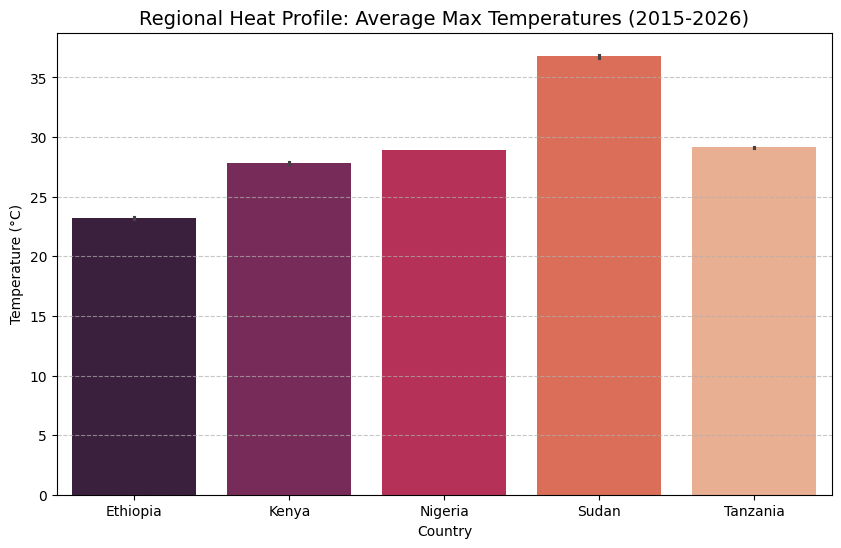

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='T2M_MAX', data=df_master, estimator='mean', palette='rocket')

plt.title('Regional Heat Profile: Average Max Temperatures (2015-2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\Bitan\AppData\Local\Temp\ipykernel_6340\3206646631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y='PRECTOTCORR', data=df_master, palette='Blues')


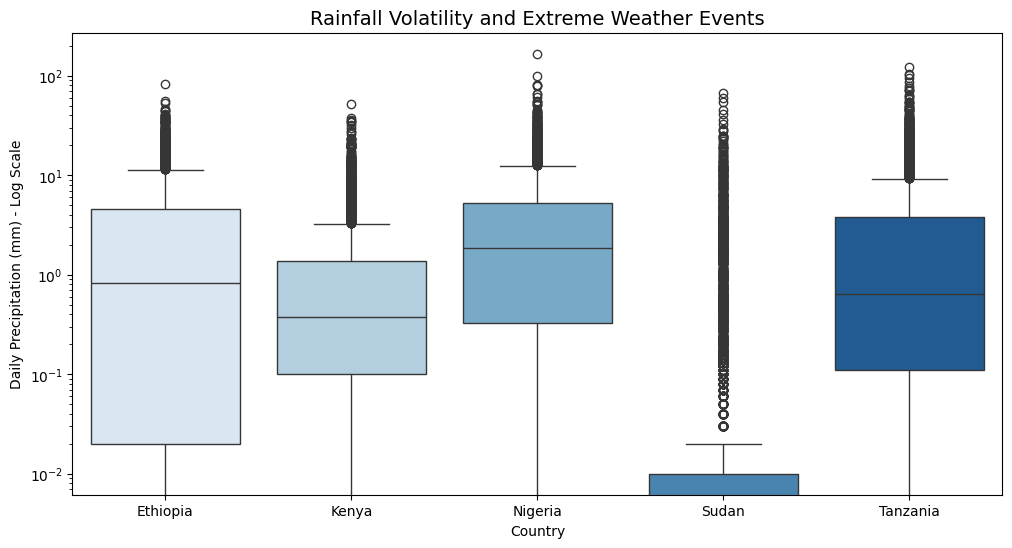

In [22]:
plt.figure(figsize=(12, 6))
# Boxplots show the 'median' (the line) and 'outliers' (the dots)
sns.boxplot(x='Country', y='PRECTOTCORR', data=df_master, palette='Blues')

plt.yscale('log') # Log scale is necessary because rain varies so much
plt.title('Rainfall Volatility and Extreme Weather Events', fontsize=14)
plt.ylabel('Daily Precipitation (mm) - Log Scale')
plt.show()

C:\Users\Bitan\AppData\Local\Temp\ipykernel_6340\996132120.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y='PRECTOTCORR', data=df_master, palette='coolwarm')


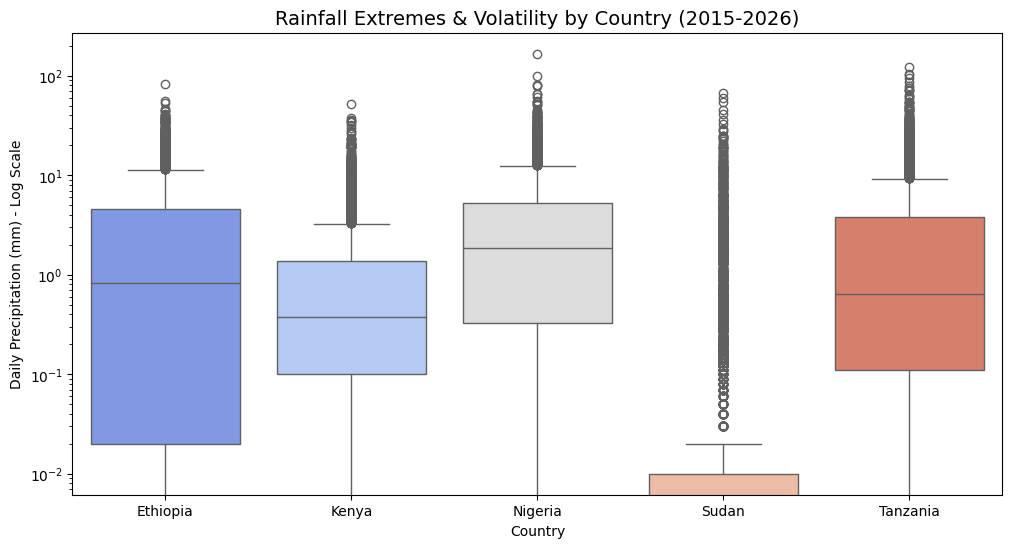

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='PRECTOTCORR', data=df_master, palette='coolwarm')

plt.yscale('log') 
plt.title('Rainfall Extremes & Volatility by Country (2015-2026)', fontsize=14)
plt.ylabel('Daily Precipitation (mm) - Log Scale')
plt.show()

In [24]:
summary = df_master.groupby('Country').agg({
    'T2M_MAX': ['mean', 'max'],
    'PRECTOTCORR': ['mean', 'max', 'std']
})

print("📊 SUMMARY FOR THE REPORT:")
print(summary)

📊 SUMMARY FOR THE REPORT:
            T2M_MAX        PRECTOTCORR                  
               mean    max        mean     max       std
Country                                                 
Ethiopia  23.199175  30.93    3.633795   82.30  6.289061
Kenya     27.838717  34.27    1.468162   51.65  3.180228
Nigeria   28.914667  32.88    4.213914  166.10  7.266742
Sudan     36.773914  45.96    0.643875   66.49  3.057672
Tanzania  29.163493  33.93    3.740256  122.65  8.003947


In [25]:
df_eth_raw = pd.read_csv('../data/ethiopia.csv') # Path to raw data
df_eth_raw['Country'] = 'Ethiopia'
df_eth_raw.to_csv('data/ethiopia_clean.csv', index=False)
print("Ethiopia clean file has been manually refreshed!")

Ethiopia clean file has been manually refreshed!
